<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [88]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-06-02 14:55:19--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.1’

survey-results-publ 100%[===================>] 201.62M  37.4MB/s    in 5.7s    

2026-06-02 14:55:27 (35.3 MB/s) - ‘survey-results-public.sqlite.1’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [89]:
!pip install pandas

In [90]:
!pip install matplotlib

In [91]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [92]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


In [93]:
# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

#### Demo 2: List All Tables


In [94]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [95]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


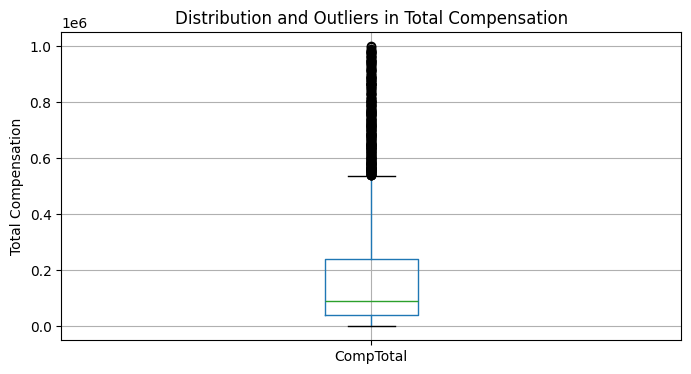

In [96]:
# your code goes here
QUERY = """
SELECT DISTINCT CompTotal
FROM main 
"""
df = pd.read_sql_query(QUERY, conn)

#drop missing values
df = df.dropna(subset=['CompTotal'])

#keep only sensible values
df = df[(df['CompTotal'] > 0) & (df['CompTotal'] < 1_000_000)]

#plot boxplot
plt.figure(figsize=(8, 4))
df.boxplot(column='CompTotal')

plt.title('Distribution and Outliers in Total Compensation')
plt.ylabel('Total Compensation')

plt.show()


**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


KeyError: "None of [Index(['Age_Numeric'], dtype='str')] are in the [columns]"

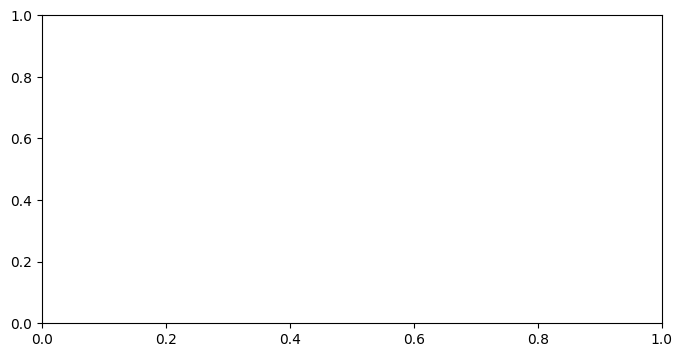

In [98]:
# your code goes here

QUERY = """
SELECT
    CASE
        WHEN TRIM(Age) = 'Under 18 years old' THEN 16
        WHEN TRIM(Age) = '18-24 years old' THEN 21
        WHEN TRIM(Age) = '25-34 years old' THEN 30
        WHEN TRIM(Age) = '35-44 years old' THEN 40
        WHEN TRIM(Age) = '45-54 years old' THEN 50
        WHEN TRIM(Age) = '55-64 years old' THEN 60
        WHEN TRIM(Age) = '65 years or older' THEN 70
        ELSE NULL
    END AS Age_Numeric
FROM main
"""
df_Age = pd.read_sql_query(QUERY, conn)

df_Age = df_Age.dropna(subset=['Age_Numeric'])

#plot boxplot
plt.figure(figsize=(8, 4))
df.boxplot(column='Age_Numeric')

plt.title('Box Plot of Age')
plt.ylabel('Age')

plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


<Figure size 1200x1000 with 0 Axes>

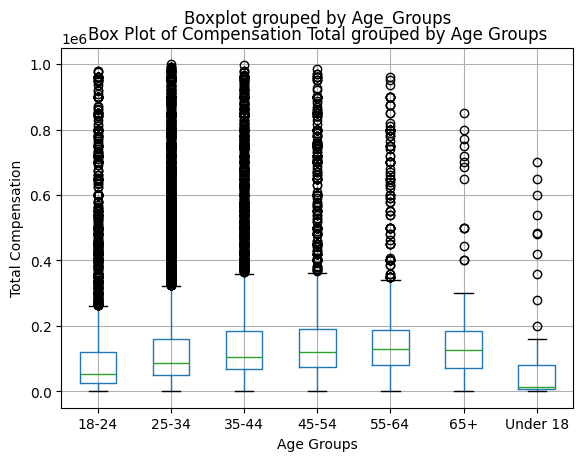

In [99]:
# your code goes here
QUERY = """
SELECT DISTINCT CompTotal
FROM main 
"""
df_Comp = pd.read_sql_query(QUERY, conn)

QUERY = """
SELECT
    CompTotal,
    CASE
        WHEN TRIM(Age) = 'Under 18 years old' THEN 'Under 18'
        WHEN TRIM(Age) = '18-24 years old' THEN '18-24'
        WHEN TRIM(Age) = '25-34 years old' THEN '25-34'
        WHEN TRIM(Age) = '35-44 years old' THEN '35-44'
        WHEN TRIM(Age) = '45-54 years old' THEN '45-54'
        WHEN TRIM(Age) = '55-64 years old' THEN '55-64'
        WHEN TRIM(Age) = '65 years or older' THEN '65+'
        ELSE NULL
    END AS Age_Groups
FROM main
"""
df = pd.read_sql_query(QUERY, conn)

#keep only sensible values
df = df.dropna(subset=['CompTotal', 'Age_Groups'])

#keep only sensible values
df = df[(df['CompTotal'] > 0) & (df['CompTotal'] < 1_000_000)]

#plot boxplot
plt.figure(figsize=(12, 10))
df.boxplot(column='CompTotal', by='Age_Groups')

plt.title('Box Plot of Compensation Total grouped by Age Groups')
plt.xlabel('Age Groups')
plt.ylabel('Total Compensation')

plt.show()
#shows outliers, median per age group)

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


<Figure size 3000x3000 with 0 Axes>

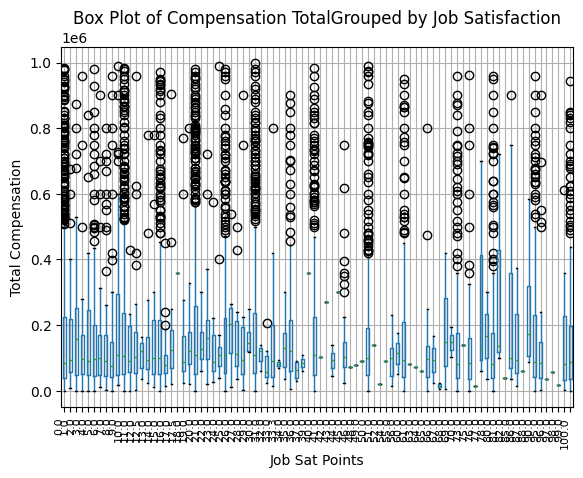

In [100]:
# your code goes here
QUERY = """
SELECT DISTINCT JobSatPoints_6, CompTotal
FROM main 
"""
df = pd.read_sql_query(QUERY, conn)

df = df.dropna(subset=['JobSatPoints_6', 'CompTotal'])

#keep only sensible values
df = df[(df['CompTotal'] > 0) & (df['CompTotal'] < 1_000_000)]
df = df.sort_values('JobSatPoints_6')

#plot boxplot
plt.figure(figsize=(30, 30))
df.boxplot(column='CompTotal', by='JobSatPoints_6')

plt.title('Box Plot of Compensation TotalGrouped by Job Satisfaction')
plt.suptitle('') #removes automatic subtitles
plt.xlabel('Job Sat Points')
plt.ylabel('Total Compensation')
plt.xticks(rotation=90, ha='right', fontsize=8)

plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [101]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])

CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


In [102]:
QUERY = """
SELECT DISTINCT DevType
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
print(df)

                                          DevType
0                                             NaN
1                           Developer, full-stack
2                            Developer Experience
3                                         Student
4                             Academic researcher
5                                 Project manager
6                              Developer Advocate
7                             Developer, back-end
8                         Other (please specify):
9                            Developer, front-end
10                         Database administrator
11  Developer, desktop or enterprise applications
12                  Cloud infrastructure engineer
13  Data scientist or machine learning specialist
14                    Research & Development role
15    Developer, embedded applications or devices
16                           System administrator
17                              DevOps specialist
18                            Engineering manager


       ConvertedCompYearly                DevType
0                      NaN                    NaN
1                      NaN  Developer, full-stack
2                      NaN   Developer Experience
3                      NaN  Developer, full-stack
4                      NaN  Developer, full-stack
...                    ...                    ...
65432                  NaN             Blockchain
65433                  NaN                    NaN
65434                  NaN      Developer, mobile
65435                  NaN    Developer, back-end
65436                  NaN                    NaN

[65437 rows x 2 columns]


<Figure size 1000x800 with 0 Axes>

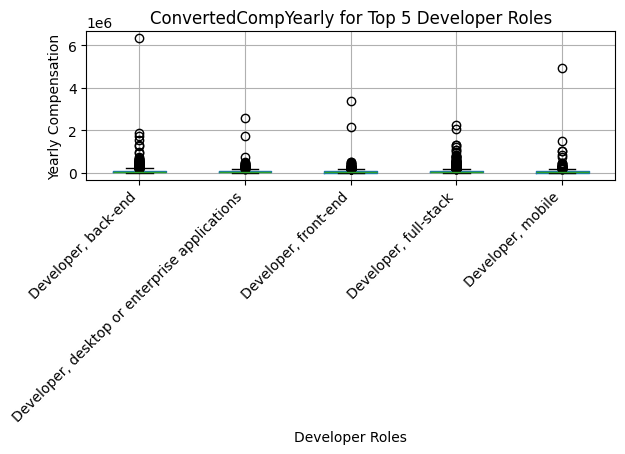

In [112]:
# your code goes here
QUERY = """
SELECT ConvertedCompYearly, DevType
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
print(df)

df = df.dropna(subset=['DevType', 'ConvertedCompYearly'])

df['DevType'] = df['DevType'].str.split(';')
df = df.explode('DevType')
df['DevType'] = df['DevType'].str.strip()

#top 5 
top_roles = df['DevType'].value_counts().head(5).index
df_top5 = df[df['DevType'].isin(top_roles)]


#plot boxplot
plt.figure(figsize=(10, 8))
df_top5.boxplot(column='ConvertedCompYearly', by='DevType')

plt.title('ConvertedCompYearly for Top 5 Developer Roles')
plt.suptitle('') #removes automatic subtitles
plt.xlabel('Developer Roles')
plt.ylabel('Yearly Compensation')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


       CompTotal                                            Country
0            NaN                           United States of America
1            NaN  United Kingdom of Great Britain and Northern I...
2            NaN  United Kingdom of Great Britain and Northern I...
3            NaN                                             Canada
4            NaN                                             Norway
...          ...                                                ...
65432        NaN                                                NaN
65433        NaN                                                NaN
65434        NaN                                                NaN
65435        NaN                                            Germany
65436        NaN                                                NaN

[65437 rows x 2 columns]
Top 5 countries: ['United States of America', 'Germany', 'UK and Ireland', 'France', 'Ukraine']


<Figure size 1600x800 with 0 Axes>

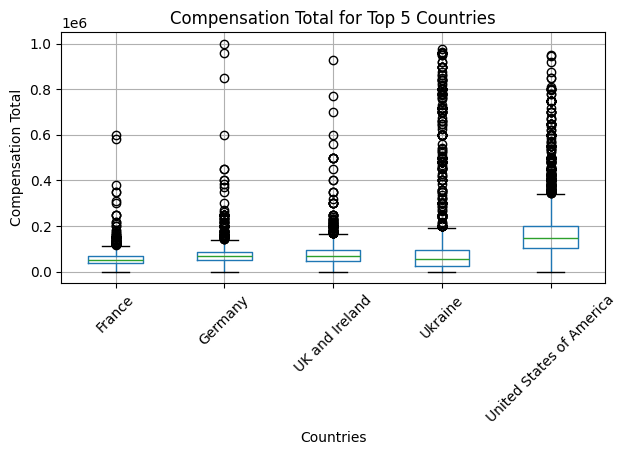

In [109]:
# your code goes here
QUERY = """
SELECT CompTotal, Country
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
print(df)

df = df.dropna(subset=['Country', 'CompTotal'])

df = df[(df['CompTotal'] > 0) & (df['CompTotal'] < 1_000_000)]

df['Country'] = df['Country'].str.replace('United Kingdom of Great Britain and Northern Ireland', 'UK and Ireland', regex=False).str.replace(r',.*', '', regex=True).str.strip()

top_countries = df['Country'].value_counts().head(5).index.tolist()
print("Top 5 countries:", top_countries)
df_top = df[df['Country'].isin(top_countries)].copy()


plt.figure(figsize=(16, 8))
df_top.boxplot(column='CompTotal', by='Country')

plt.title('Compensation Total for Top 5 Countries')
plt.suptitle('') #removes automatic subtitles
plt.xlabel('Countries')
plt.ylabel('Compensation Total')
plt.xticks(rotation=45, fontsize=10)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [106]:
# your code goes here
QUERY = """
SELECT DISTINCT Employment
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
print(df)


                                            Employment
0                                  Employed, full-time
1                                   Student, full-time
2    Student, full-time;Not employed, but looking f...
3    Independent contractor, freelancer, or self-em...
4               Not employed, and not looking for work
..                                                 ...
105  Not employed, but looking for work;Independent...
106                         Student, full-time;Retired
107  Employed, full-time;Not employed, but looking ...
108  Not employed, and not looking for work;Student...
109  Not employed, but looking for work;Independent...

[110 rows x 1 columns]


<Figure size 1600x800 with 0 Axes>

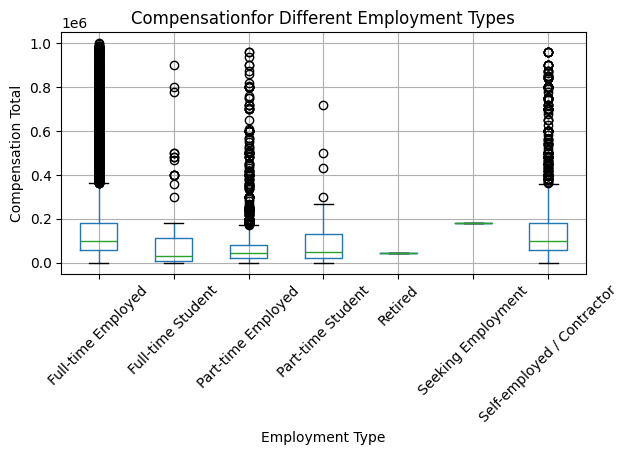

In [111]:
QUERY = """
SELECT
    CASE
        WHEN Employment LIKE '%Employed, full-time%' THEN 'Full-time Employed'
        WHEN Employment LIKE '%Employed, part-time%' THEN 'Part-time Employed'
        WHEN Employment LIKE '%Student, full-time%' THEN 'Full-time Student'
        WHEN Employment LIKE '%Student, part-time%' THEN 'Part-time Student'
        WHEN Employment LIKE '%Independent contractor%' THEN 'Self-employed / Contractor'
        WHEN Employment LIKE '%Not employed, but looking for work%' THEN 'Seeking Employment'
        WHEN Employment LIKE '%Not employed, and not looking for work%' THEN 'Not-Seeking Employment'
        WHEN Employment LIKE '%Retired%' THEN 'Retired'
        ELSE 'Other / Mixed'
    END AS Employment_Groups,
    CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""
df= pd.read_sql_query(QUERY, conn)

df = df.dropna(subset=['Employment_Groups', 'CompTotal'])

df = df[(df['CompTotal'] > 0) & (df['CompTotal'] < 1_000_000)]


plt.figure(figsize=(16, 8))
df.boxplot(column='CompTotal', by='Employment_Groups')

plt.title('Compensationfor Different Employment Types')
plt.suptitle('') #removes automatic subtitles
plt.xlabel('Employment Type')
plt.ylabel('Compensation Total')
plt.xticks(rotation=45, fontsize=10)
plt.tight_layout()
plt.show()





**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


            YearsCodePro  JobSatPoints_6
0                    NaN             NaN
1                     17             0.0
2                     27             NaN
3                      7             NaN
4                     11             NaN
...                  ...             ...
1434                  20            34.0
1435                 NaN            19.0
1436                  15            12.5
1437  More than 50 years            15.0
1438                  24            63.0

[1439 rows x 2 columns]


<Figure size 1600x800 with 0 Axes>

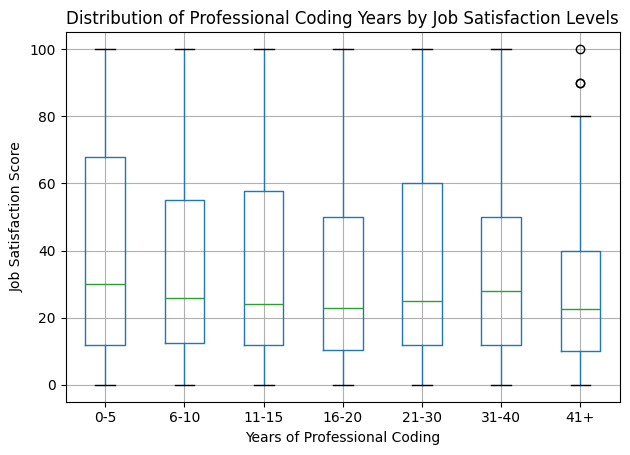

In [131]:
# your code goes here
QUERY = """
SELECT DISTINCT YearsCodePro, JobSatPoints_6
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
print(df)

df = df.dropna(subset=['YearsCodePro', 'JobSatPoints_6']).copy()

#Cleaning YearsCodePro
df['YearsCodePro'] = df['YearsCodePro'].replace({'Less than 1 year': 0.5,
                                                 'More than 50 years': 51})

#Convert to numeric
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

df = df.dropna(subset=['YearsCodePro', 'JobSatPoints_6'])

bins = [0, 5, 10, 15, 20, 30, 40, 55]
labels = ['0-5', '6-10', '11-15', '16-20', '21-30', '31-40', '41+']

df['YearsGroup'] = pd.cut(df['YearsCodePro'], bins=bins, labels=labels, include_lowest=True)

df = df.dropna(subset=['YearsGroup'])

df = df.sort_values('YearsGroup')

plt.figure(figsize=(16, 8))
df.boxplot(column='JobSatPoints_6', by='YearsGroup')

plt.title('Distribution of Professional Coding Years by Job Satisfaction Levels')
plt.suptitle('') #removes automatic subtitles
plt.xlabel('Years of Professional Coding')
plt.ylabel('Job Satisfaction Score')
plt.xticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [ ]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
